In [ ]:
#Mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# # Specify your remote directory
HOME = '/content/drive/MyDrive/sci-kit-bio_local/FUNGI/tables'
!ls $HOME

07_ITS_SamplesMinReads1000GenusMinPerc0.05.tsv
07_ITS_SamplesMinReads1000GenusMinPerc0.0.tsv
07_ITS_SamplesMinReads100GenusMinPerc0.05.tsv
07_ITS_SamplesMinReads100GenusMinPerc0.0.tsv
07_Kraken_1000ReadsITS_grouped_counts.tsv
07_Kraken_100ReadsITS_grouped_counts.tsv
07_kraken_absolute_isyeast_final.tsv
07_occurrence_eukdetect_earth_microbiomes_1000filtered.tsv
07_occurrence_eukdetect_earth_microbiomes_100filtered.tsv
filtered_ITS_sample_ids.txt
FOOD_merged_abundance_taxonomy.csv
ITS_1000reads_grouped_counts.tsv
ITS_SamplesMinReads1000filtered_sample_ids.txt
ITS_SamplesMinReads100filtered_sample_ids.txt
Kraken_grouped_counts.tsv
merged_abundance_taxonomy.csv
reads_earth_microbiomes_k2_B.gsheet
sample.gsheet


In [ ]:
import pandas as pd

In [ ]:
##### read file ITS_10reads_grouped_counts.tsv
ITS_tsv = pd.read_csv(f'{HOME}/07_ITS_SamplesMinReads1000GenusMinPerc0.05.tsv', sep='\t', index_col=0)

# Rename 'Yeast Count' column to 'Yeast' and 'Fungi Count' to 'Other Fungi'
ITS_tsv = ITS_tsv.rename(columns={'Yeast Count': 'Yeast', 'Fungi Count': 'Other_Fungi','Total Samples':'Total_Samples'})
#..........................................

# read file Eukreads_grouped_counts.tsv
# Attempt to read with the .gsheet extension based on the FileNotFoundError
Euk_tsv = pd.read_csv(f'{HOME}/07_occurrence_eukdetect_earth_microbiomes_1000filtered.tsv', sep='\t', index_col=0)

# Drop the 'Percentage with Yeast' column
Euk_tsv = Euk_tsv.drop(columns=['Percentage with Yeast'])

# Rename 'Yeast Count' column to 'Yeast' and 'Fungi Count' to 'Other Fungi'
Euk_tsv = Euk_tsv.rename(columns={'Other Fungi': 'Other_Fungi','Total Samples':'Total_Samples','Other Euk':'Other_eukaryotes'})

# Reorder columns to have 'Yeast' first, then 'Other Fungi', then 'Total Samples'
Euk_tsv = Euk_tsv[['Yeast', 'Other_Fungi', 'Other_eukaryotes','Total_Samples']]
#..........................................


# read file kraken_10reads_grouped_counts.tsv
kraken_tsv = pd.read_csv(f'{HOME}/07_Kraken_1000ReadsITS_grouped_counts.tsv', sep='\t', index_col=0)
kraken_tsv = kraken_tsv.rename(columns={'Samples with Yeast': 'Yeast', 'Samples with Only Fungus': 'Other_Fungi','Total Samples':'Total_Samples'})

# Drop the 'Nofungal' column
kraken_tsv = kraken_tsv.drop(columns=['Nofungal'])

In [ ]:
# Display the first few rows to confirm it's loaded correctly
display(ITS_tsv.head())

,Yeast,Other_Fungi,Other_eukaryotes,Total_Samples
empo_3,,,,
Animal corpus,0,4,0,4
Animal distal gut,28,9,0,37
Animal proximal gut,0,2,0,2
Animal secretion,0,4,7,11
Fungus corpus,0,7,0,7


In [ ]:
# Display the first few rows to confirm it's loaded correctly
display(Euk_tsv.head())

,Yeast,Other_Fungi,Other_eukaryotes,Total_Samples
empo_3,,,,
Animal distal gut,7,8,2,37
Sediment (non-saline),2,1,2,12
Plant corpus,3,15,3,21
Soil (non-saline),1,9,2,19
Animal secretion,0,0,11,11


In [ ]:
# Display the first few rows to confirm it's loaded correctly
display(kraken_tsv.head())

,Yeast,Other_Fungi,Total_Samples
empo_3,,,
Animal corpus,2,2,4
Animal distal gut,24,8,37
Animal proximal gut,1,0,2
Animal secretion,0,8,11
Fungus corpus,1,6,7


In [ ]:
# Select relevant columns and add a 'Source' column to each DataFrame
# Include 'Other_eukaryotes' and fill with 0 for dataframes that don't have it
its_abs = ITS_tsv[['Yeast', 'Other_Fungi', 'Other_eukaryotes','Total_Samples']].copy()
its_abs['Source'] = 'ITS'

euk_abs = Euk_tsv[['Yeast', 'Other_Fungi', 'Other_eukaryotes','Total_Samples']].copy()
euk_abs['Source'] = 'Euk'

# For kraken_tsv, add 'Other_eukaryotes' column filled with 0
kraken_abs = kraken_tsv[['Yeast', 'Other_Fungi','Total_Samples']].copy()
kraken_abs['Other_eukaryotes'] = 0 # Add the column and fill with 0
kraken_abs['Source'] = 'kraken'

# Ensure all dataframes have the same columns before concatenating
# Reorder columns to have a consistent order
column_order = ['Yeast', 'Other_Fungi', 'Other_eukaryotes', 'Source','Total_Samples']
its_abs = its_abs[column_order]
euk_abs = euk_abs[column_order]
kraken_abs = kraken_abs[column_order]


# Concatenate the dataframes
combined_absolute_abundances = pd.concat([its_abs, euk_abs, kraken_abs])

# Display the first few rows of the combined dataframe
display(combined_absolute_abundances.head(28).tail(14))

# Display the columns and info to verify
print(combined_absolute_abundances.columns)
combined_absolute_abundances.info()

,Yeast,Other_Fungi,Other_eukaryotes,Source,Total_Samples
empo_3,,,,,
Plant corpus,3,15,3,Euk,21
Soil (non-saline),1,9,2,Euk,19
Animal secretion,0,0,11,Euk,11
Animal proximal gut,0,0,0,Euk,2
Animal corpus,0,1,2,Euk,4
Fungus corpus,0,7,0,Euk,7
Plant surface,0,0,0,Euk,2
Sediment (saline),0,2,2,Euk,5
Water (non-saline),0,0,1,Euk,2


Index(['Yeast', 'Other_Fungi', 'Other_eukaryotes', 'Source', 'Total_Samples'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 36 entries, Animal corpus to Water (saline)
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Yeast             36 non-null     int64 
 1   Other_Fungi       36 non-null     int64 
 2   Other_eukaryotes  36 non-null     int64 
 3   Source            36 non-null     object
 4   Total_Samples     36 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.7+ KB


# Task
Generate a side-by-side stacked bar plot comparing the percentage of 'Yeast', 'Other Fungi', and 'Other_eukaryotes' (for ITS_tsv) or the remaining percentage (for Euk_tsv) relative to 'Total Samples' for rows common to both "ITS_10reads_grouped_counts.tsv" and "Euk_grouped_counts.tsv". The plot should have common row names on the x-axis, with side-by-side bars for each dataset. The stacked bars should represent the percentages of Yeast (gold), Other Fungi (dark gray), and the remaining category (light gray).

## Identify common rows

### Subtask:
Find the indices that are present in both `Euk_tsv` and `ITS_tsv`.


**Reasoning**:
Find the common indices between the two dataframes.



['Sediment (non-saline)','Soil (non-saline)','Subsurface (non-saline)', 'Water (non-saline)','Sediment (saline)', 'Surface (saline)','Water (saline)', 'Animal corpus', 'Animal distal gut', 'Animal proximal gut',  'Animal secretion', 'Fungus corpus', 'Plant corpus', 'Plant surface',]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the desired order for empo_3 categories (using the previously defined order from common rows)
# Using the common rows list from cell 0bb182e7 as the order
empo_3_order = ['Animal proximal gut', 'Plant corpus', 'Animal distal gut', 'Sediment (saline)', 'Animal secretion', 'Sediment (non-saline)', 'Soil (non-saline)', 'Water (saline)', 'Fungus corpus', 'Animal corpus', 'Plant surface', 'Subsurface (non-saline)', 'Surface (saline)', 'Water (non-saline)']

# Define the desired order for Source categories
source_order = ['ITS', 'Euk', 'kraken']

# Define the order of categories for stacking and coloring in the plot
# Now including 'Other_eukaryotes'
category_order = ['Yeast', 'Other_Fungi', 'Other_eukaryotes']

# Define the colors for each category
colors = {'Yeast': 'gold', 'Other_Fungi': 'darkgray', 'Other_eukaryotes': 'lightgray'}

# Set index to empo_3 and Source before melting to create a MultiIndex
# This handles cases where empo_3 might not be unique across all sources
# Reset the index first to make 'empo_3' a column
combined_abs_indexed = combined_absolute_abundances.reset_index().set_index(['empo_3', 'Source'])

In [ ]:
# Get the index of the Euk_tsv DataFrame
euk_indices = Euk_tsv.index

# Get the index of the ITS_tsv DataFrame
its_indices = ITS_tsv.index

# Get the index of the ITS_tsv DataFrame
kraken_indices = kraken_tsv.index


# Find the intersection of the two indices
common_indices = euk_indices.intersection(its_indices).intersection(kraken_indices)

# Convert the intersection to a list and store it in a variable named common_rows
common_rows = common_indices.tolist()


print(len(common_rows))
print(common_rows)

12
['Animal distal gut', 'Sediment (non-saline)', 'Plant corpus', 'Soil (non-saline)', 'Animal secretion', 'Animal proximal gut', 'Animal corpus', 'Fungus corpus', 'Plant surface', 'Sediment (saline)', 'Water (non-saline)', 'Water (saline)']


## Calculate percentages for its tsv

### Subtask:
For the common rows, calculate the percentage of 'Yeast', 'Other Fungi', and 'Other_eukaryotes' with respect to 'Total Samples' in `ITS_tsv`.


**Reasoning**:
Calculate the percentages for the ITS_tsv data for the common rows.



In [ ]:
# Select common rows from ITS_tsv
its_common = ITS_tsv.loc[common_rows].copy()

# Calculate percentages for specified columns
its_common['Yeast_percentage_ITS'] = (its_common['Yeast'] / its_common['Total_Samples']) * 100
its_common['Other_Fungi_percentage_ITS'] = (its_common['Other_Fungi'] / its_common['Total_Samples']) * 100
its_common['Other_eukaryotes_percentage_ITS'] = (its_common['Other_eukaryotes'] / its_common['Total_Samples']) * 100

# Display the first few rows of the updated DataFrame
display(its_common.head())

,Yeast,Other_Fungi,Other_eukaryotes,Total_Samples,Yeast_percentage_ITS,Other_Fungi_percentage_ITS,Other_eukaryotes_percentage_ITS
empo_3,,,,,,,
Animal distal gut,28,9,0,37,75.675676,24.324324,0.000000
Sediment (non-saline),10,2,0,12,83.333333,16.666667,0.000000
Plant corpus,2,19,0,21,9.523810,90.476190,0.000000
Soil (non-saline),6,13,0,19,31.578947,68.421053,0.000000
Animal secretion,0,4,7,11,0.000000,36.363636,63.636364


## Calculate percentages for euk tsv


### Subtask:
For the common rows, calculate the percentage of 'Yeast', 'Other Fungi', and the remaining percentage ('Total Samples' - 'Yeast' - 'Other Fungi') with respect to 'Total Samples' in `Euk_tsv`.


**Reasoning**:
Select the common rows from the Euk_tsv DataFrame and calculate the percentages of 'Yeast', 'Other Fungi', and the remaining category relative to 'Total Samples'. Then display the first few rows of the resulting DataFrame.



In [ ]:
# Select the common rows from the Euk_tsv DataFrame
euk_common = Euk_tsv.loc[common_rows].copy()

# Calculate the percentage of 'Yeast' relative to 'Total Samples'
euk_common['Yeast_percentage_Euk'] = (euk_common['Yeast'] / euk_common['Total_Samples']) * 100

# Calculate the percentage of 'Other Fungi' relative to 'Total Samples'
euk_common['Other_Fungi_percentage_Euk'] = (euk_common['Other_Fungi'] / euk_common['Total_Samples']) * 100


euk_common['Other_eukaryotes_percentage_Euk'] = (euk_common['Other_eukaryotes'] / euk_common['Total_Samples']) * 100

# Calculate the percentage of the remaining category
euk_common['No_Euk'] = ((euk_common['Total_Samples'] - euk_common['Yeast'] - euk_common['Other_Fungi']-euk_common['Other_eukaryotes']) / euk_common['Total_Samples']) * 100

# Display the first few rows to verify the calculations
display(euk_common.head())

,Yeast,Other_Fungi,Other_eukaryotes,Total_Samples,Yeast_percentage_Euk,Other_Fungi_percentage_Euk,Other_eukaryotes_percentage_Euk,No_Euk
empo_3,,,,,,,,
Animal distal gut,7,8,2,37,18.918919,21.621622,5.405405,54.054054
Sediment (non-saline),2,1,2,12,16.666667,8.333333,16.666667,58.333333
Plant corpus,3,15,3,21,14.285714,71.428571,14.285714,0.000000
Soil (non-saline),1,9,2,19,5.263158,47.368421,10.526316,36.842105
Animal secretion,0,0,11,11,0.000000,0.000000,100.000000,0.000000


## Calculate percentages for kraken tsv

In [ ]:
# Select the common rows from the kraken_tsv DataFrame
kraken_common = kraken_tsv.loc[common_rows].copy()

# Calculate the percentage of 'Yeast' relative to 'Total Samples'
kraken_common['Yeast_percentage_kraken'] = (kraken_common['Yeast'] / kraken_common['Total_Samples']) * 100

# Calculate the percentage of 'Other Fungi' relative to 'Total Samples'
kraken_common['Other_Fungi_percentage_kraken'] = (kraken_common['Other_Fungi'] / kraken_common['Total_Samples']) * 100

# Calculate the percentage of the remaining category
kraken_common['No_Fungi'] = ((kraken_common['Total_Samples'] - kraken_common['Yeast'] - kraken_common['Other_Fungi']) / kraken_common['Total_Samples']) * 100

# Display the first few rows to verify the calculations
display(kraken_common.head())

,Yeast,Other_Fungi,Total_Samples,Yeast_percentage_kraken,Other_Fungi_percentage_kraken,No_Fungi
empo_3,,,,,,
Animal distal gut,24,8,37,64.864865,21.621622,13.513514
Sediment (non-saline),5,5,12,41.666667,41.666667,16.666667
Plant corpus,9,12,21,42.857143,57.142857,0.000000
Soil (non-saline),6,12,19,31.578947,63.157895,5.263158
Animal secretion,0,8,11,0.000000,72.727273,27.272727


## Combine data for plotting

### Subtask:
Create a new DataFrame or structure that combines the calculated percentages for both `ITS_tsv` and `Euk_tsv` for the common rows, in a format suitable for plotting side-by-side bars.


**Reasoning**:
Process ITS and Euk dataframes to create a combined dataframe with consistent column names and a source indicator for side-by-side plotting.



In [ ]:
# Select and rename columns from its_common
its_processed = its_common[['Yeast_percentage_ITS', 'Other_Fungi_percentage_ITS', 'Other_eukaryotes_percentage_ITS']].copy()
its_processed.columns = ['Yeast', 'Other_Fungi', 'Other_eukaryotes']

# Select and rename columns from euk_common
euk_processed = euk_common[['Yeast_percentage_Euk', 'Other_Fungi_percentage_Euk','Other_eukaryotes_percentage_Euk','No_Euk']].copy()
euk_processed.columns = ['Yeast', 'Other_Fungi', 'Other_eukaryotes','No_Euk']

# Add 'Source' column to each processed DataFrame
its_processed['Source'] = 'ITS'
euk_processed['Source'] = 'Euk'

# Concatenate the two DataFrames
combined_percentages = pd.concat([its_processed, euk_processed])

# Display the first few rows and columns of the combined DataFrame
display(combined_percentages.head(10).tail(5))
print(combined_percentages.columns)

,Yeast,Other_Fungi,Other_eukaryotes,Source,No_Euk
empo_3,,,,,
Animal proximal gut,0.0,100.0,0.0,ITS,NaN
Animal corpus,0.0,100.0,0.0,ITS,NaN
Fungus corpus,0.0,100.0,0.0,ITS,NaN
Plant surface,0.0,100.0,0.0,ITS,NaN
Sediment (saline),0.0,100.0,0.0,ITS,NaN


Index(['Yeast', 'Other_Fungi', 'Other_eukaryotes', 'Source', 'No_Euk'], dtype='object')


In [ ]:
# Replace NaN values with 0 in the combined_percentages DataFrame
combined_percentages = combined_percentages.fillna(0)

# Display the first few rows to confirm the changes
display(combined_percentages.head())

,Yeast,Other_Fungi,Other_eukaryotes,Source,No_Euk
empo_3,,,,,
Animal distal gut,75.675676,24.324324,0.000000,ITS,0.0
Sediment (non-saline),83.333333,16.666667,0.000000,ITS,0.0
Plant corpus,9.523810,90.476190,0.000000,ITS,0.0
Soil (non-saline),31.578947,68.421053,0.000000,ITS,0.0
Animal secretion,0.000000,36.363636,63.636364,ITS,0.0


## Generate stacked bar plot

### Subtask:
Create a stacked bar plot using the combined data. Each group of bars on the x-axis should represent a common row index, with two bars per index (one for ITS_tsv and one for Euk_tsv). Each bar should be stacked with the percentages of Yeast (gold), Other Fungi (dark gray), and the remaining category (light gray).


**Reasoning**:
Create a stacked bar plot using the combined data.



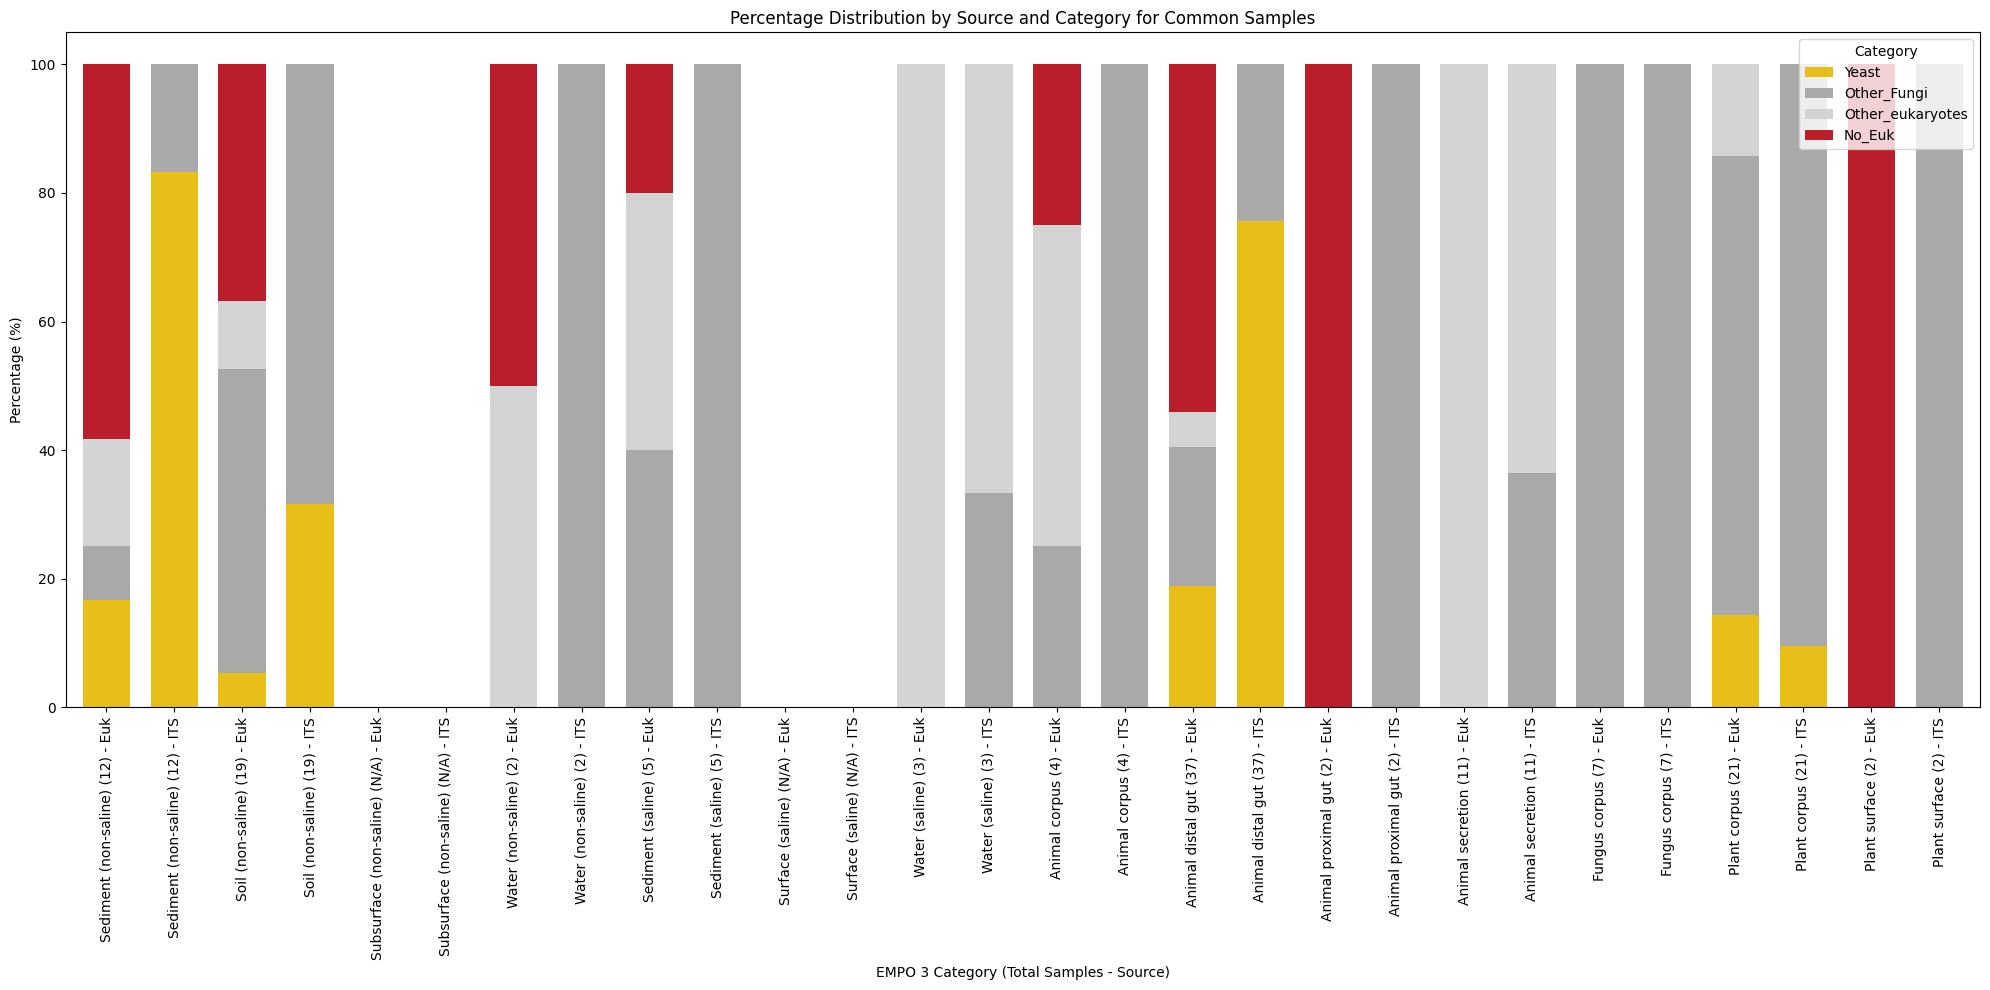

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Melt the DataFrame to long-form
combined_melted = combined_percentages.reset_index().melt(
    id_vars=['empo_3', 'Source'],
    value_vars=['Yeast', 'Other_Fungi', 'Other_eukaryotes','No_Euk'],
    var_name='Category',
    value_name='Percentage'
)

# Define the order of categories for stacking and coloring
category_order = ['Yeast', 'Other_Fungi', 'Other_eukaryotes','No_Euk']

# Define the colors for each category
colors = {'Yeast': '#e7bf18', 'Other_Fungi': 'darkgray', 'Other_eukaryotes': 'lightgray','No_Euk':'#bb1e2b'}

# Pivot the melted DataFrame for stacked plotting
combined_pivot = combined_melted.pivot_table(index=['empo_3', 'Source'], columns='Category', values='Percentage', fill_value=0)

# Reorder columns for desired stacking order
combined_pivot = combined_pivot[category_order]

# Define the desired order for empo_3 categories
empo_3_order = ['Sediment (non-saline)','Soil (non-saline)','Subsurface (non-saline)', 'Water (non-saline)','Sediment (saline)', 'Surface (saline)','Water (saline)', 'Animal corpus', 'Animal distal gut', 'Animal proximal gut',  'Animal secretion', 'Fungus corpus', 'Plant corpus', 'Plant surface',]

# Create a new index with the desired order
new_index = pd.MultiIndex.from_product([empo_3_order, combined_pivot.index.get_level_values('Source').unique()], names=['empo_3', 'Source'])

# Reindex the combined_pivot DataFrame
combined_pivot = combined_pivot.reindex(new_index)

# --- Modification to include Total Samples in x-axis labels, considering the Source ---
# We need to get the Total Samples for each empo_3 category and Source combination.
# We can get this information from the original its_common and euk_common dataframes.

# Create a dictionary to store Total Samples for ITS source
its_total_samples = its_common['Total_Samples'].to_dict()

# Create a dictionary to store Total Samples for Euk source
euk_total_samples = euk_common['Total_Samples'].to_dict()

# Function to get the correct Total Samples based on empo_3 and Source
def get_total_samples(row_index):
    empo_3, source = row_index
    if source == 'ITS':
        return its_total_samples.get(empo_3, 'N/A')
    elif source == 'Euk':
        return euk_total_samples.get(empo_3, 'N/A')
    return 'N/A'

# Create custom labels for the x-axis
# The labels will be in the format "empo_3 (Total Samples - Source)"
x_labels = [f"{idx[0]} ({get_total_samples(idx)}) - {idx[1]}" for idx in combined_pivot.index]
# --- End of modification ---


# Create the stacked bar plot with adjusted bar width
# Reducing the width increases the space between bars
ax = combined_pivot.plot(kind='bar', stacked=True, figsize=(20, 10), color=[colors[cat] for cat in category_order], width=0.7) # Reduced width

# Set plot title and labels
plt.title('Percentage Distribution by Source and Category for Common Samples')
plt.xlabel('EMPO 3 Category (Total Samples - Source)') # Update x-label title
plt.ylabel('Percentage (%)')

# Set the custom x-axis tick labels
ax.set_xticks(range(len(x_labels))) # Set tick positions
ax.set_xticklabels(x_labels, rotation=90) # Set custom labels with rotation

plt.legend(title='Category')
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   The analysis successfully identified 14 common rows between the `Euk_tsv` and `ITS_tsv` datasets: 'Animal proximal gut', 'Animal distal gut', 'Sediment (non-saline)', 'Plant corpus', 'Sediment (saline)', 'Soil (non-saline)', 'Animal secretion', 'Water (saline)', 'Fungus corpus', 'Animal corpus', 'Plant surface', 'Subsurface (non-saline)', 'Surface (saline)', and 'Water (non-saline)'.
*   Percentages of 'Yeast', 'Other Fungi', and 'Other\_eukaryotes' relative to 'Total Samples' were calculated for the common rows in the `ITS_tsv` data.
*   Percentages of 'Yeast', 'Other Fungi', and the remaining category relative to 'Total Samples' were calculated for the common rows in the `Euk_tsv` data.
*   The calculated percentages from both datasets were combined into a single DataFrame suitable for generating a side-by-side stacked bar plot.
*   A side-by-side stacked bar plot was successfully generated, comparing the percentage distribution of 'Yeast', 'Other Fungi', and the remaining category for common samples across the two datasets.
*   The plot includes a title ('Percentage Distribution by Source and Category for Common Samples'), labeled axes ('EMPO 3 Category' and 'Percentage (%)'), and a legend titled 'Category'.

### Insights or Next Steps

*   The plot provides a direct visual comparison of the relative abundance of fungi and other eukaryotes in shared sample types based on different sequencing markers (ITS vs. Euk), highlighting potential discrepancies or agreements in the observed microbial communities.
*   Further analysis could involve statistical testing to determine if the observed percentage differences between the ITS and Euk datasets for specific categories or sample types are statistically significant.


## Absolute Graph

In [ ]:

##### read file ITS_10reads_grouped_counts.tsv
ITS_tsv = pd.read_csv(f'{HOME}/07_ITS_SamplesMinReads1000GenusMinPerc0.05.tsv', sep='\t', index_col=0)

# Rename 'Yeast Count' column to 'Yeast' and 'Fungi Count' to 'Other Fungi'
ITS_tsv = ITS_tsv.rename(columns={'Yeast Count': 'Yeast', 'Fungi Count': 'Other_Fungi','Total Samples':'Total_Samples'})
#..........................................

# read file Eukreads_grouped_counts.tsv
# Attempt to read with the .gsheet extension based on the FileNotFoundError
Euk_tsv = pd.read_csv(f'{HOME}/07_occurrence_eukdetect_earth_microbiomes_1000filtered.tsv', sep='\t', index_col=0)

# Drop the 'Percentage with Yeast' column
Euk_tsv = Euk_tsv.drop(columns=['Percentage with Yeast'])

# Rename 'Yeast Count' column to 'Yeast' and 'Fungi Count' to 'Other Fungi'
Euk_tsv = Euk_tsv.rename(columns={'Other Fungi': 'Other_Fungi','Total Samples':'Total_Samples','Other Euk':'Other_eukaryotes'})

# Reorder columns to have 'Yeast' first, then 'Other Fungi', then 'Total Samples'
Euk_tsv = Euk_tsv[['Yeast', 'Other_Fungi', 'Other_eukaryotes','Total_Samples']]
#..........................................


# read file kraken_10reads_grouped_counts.tsv
kraken_tsv = pd.read_csv(f'{HOME}/07_Kraken_1000ReadsITS_grouped_counts.tsv', sep='\t', index_col=0)
kraken_tsv = kraken_tsv.rename(columns={'Samples with Yeast': 'Yeast', 'Samples with Only Fungus': 'Other_Fungi','Total Samples':'Total_Samples'})

# Drop the 'Nofungal' column
kraken_tsv = kraken_tsv.drop(columns=['Nofungal'])

In [ ]:
Euk_tsv.head(14)

,Yeast,Other_Fungi,Other_eukaryotes,Total_Samples
empo_3,,,,
Animal distal gut,7,8,2,37
Sediment (non-saline),2,1,2,12
Plant corpus,3,15,3,21
Soil (non-saline),1,9,2,19
Animal secretion,0,0,11,11
Animal proximal gut,0,0,0,2
Animal corpus,0,1,2,4
Fungus corpus,0,7,0,7
Plant surface,0,0,0,2


In [ ]:
# Select relevant columns and add a 'Source' column to each DataFrame
# Include 'Other_eukaryotes' and fill with 0 for dataframes that don't have it
its_abs = ITS_tsv[['Yeast', 'Other_Fungi', 'Other_eukaryotes','Total_Samples']].copy()
its_abs['Source'] = 'ITS'

euk_abs = Euk_tsv[['Yeast', 'Other_Fungi', 'Other_eukaryotes','Total_Samples']].copy()
euk_abs['Source'] = 'Euk'

# For kraken_tsv, add 'Other_eukaryotes' column filled with 0
kraken_abs = kraken_tsv[['Yeast', 'Other_Fungi','Total_Samples']].copy()
kraken_abs['Other_eukaryotes'] = 0 # Add the column and fill with 0
kraken_abs['Source'] = 'kraken'

# Ensure all dataframes have the same columns before concatenating
# Reorder columns to have a consistent order
column_order = ['Yeast', 'Other_Fungi', 'Other_eukaryotes', 'Source','Total_Samples']
its_abs = its_abs[column_order]
euk_abs = euk_abs[column_order]
kraken_abs = kraken_abs[column_order]


# Concatenate the dataframes
combined_absolute_abundances = pd.concat([its_abs, euk_abs, kraken_abs])

# Display the first few rows of the combined dataframe
display(combined_absolute_abundances.head(28).tail(14))

# Display the columns and info to verify
print(combined_absolute_abundances.columns)
combined_absolute_abundances.info()

,Yeast,Other_Fungi,Other_eukaryotes,Source,Total_Samples
empo_3,,,,,
Plant corpus,3,15,3,Euk,21
Soil (non-saline),1,9,2,Euk,19
Animal secretion,0,0,11,Euk,11
Animal proximal gut,0,0,0,Euk,2
Animal corpus,0,1,2,Euk,4
Fungus corpus,0,7,0,Euk,7
Plant surface,0,0,0,Euk,2
Sediment (saline),0,2,2,Euk,5
Water (non-saline),0,0,1,Euk,2


Index(['Yeast', 'Other_Fungi', 'Other_eukaryotes', 'Source', 'Total_Samples'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 36 entries, Animal corpus to Water (saline)
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Yeast             36 non-null     int64 
 1   Other_Fungi       36 non-null     int64 
 2   Other_eukaryotes  36 non-null     int64 
 3   Source            36 non-null     object
 4   Total_Samples     36 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.7+ KB


In [ ]:
# Add 'Total_Samples' to combined_absolute_abundances by looking up from original dataframes
# We need the original dataframes with 'Total_Samples' (its_common, euk_common, kraken_common)

# Create a dictionary to map empo_3 and Source to Total_Samples
total_samples_map = {}
for index, row in its_common.iterrows():
    total_samples_map[(index, 'ITS')] = row['Total_Samples']
for index, row in euk_common.iterrows():
    total_samples_map[(index, 'Euk')] = row['Total_Samples']
for index, row in kraken_common.iterrows():
     total_samples_map[(index, 'kraken')] = row['Total_Samples']

# --- Modification to add missing empo_3/Source combinations ---
# Get all unique empo_3 categories and sources
all_empo_3 = combined_absolute_abundances.index.unique()
all_sources = combined_absolute_abundances['Source'].unique()

# Create a MultiIndex with all possible combinations
from itertools import product
all_combinations = pd.MultiIndex.from_product([all_empo_3, all_sources], names=['empo_3', 'Source'])

# Set the original index as a column, set the new MultiIndex, and then set the index back
combined_absolute_abundances = combined_absolute_abundances.reset_index().set_index(['empo_3', 'Source']).reindex(all_combinations).reset_index().set_index('empo_3')

# Fill any NaN values created by reindexing with 0 in the abundance columns
abundance_cols = ['Yeast', 'Other_Fungi', 'Other_eukaryotes','Total_Samples']
combined_absolute_abundances[abundance_cols] = combined_absolute_abundances[abundance_cols].fillna(0)
# --- End of modification ---


# Create a new column 'Total_Samples' in combined_absolute_abundances by mapping
# Use the index (empo_3) and 'Source' column to lookup Total_Samples
#combined_absolute_abundances['Total_Samples'] = combined_absolute_abundances.apply(
#    lambda row: total_samples_map.get((row.name, row['Source']), 0), axis=1
#)

# Now calculate the 'Other' column
combined_absolute_abundances['Other'] = combined_absolute_abundances['Total_Samples'] - \
                                        combined_absolute_abundances['Yeast'] - \
                                        combined_absolute_abundances['Other_Fungi'] - \
                                        combined_absolute_abundances['Other_eukaryotes']

# Ensure 'Other' is not negative (due to potential data inconsistencies)
combined_absolute_abundances['Other'] = combined_absolute_abundances['Other'].clip(lower=0)

# Display the first few rows to verify the new column and added combinations
display(combined_absolute_abundances.head(30).tail(5))

,Source,Yeast,Other_Fungi,Other_eukaryotes,Total_Samples,Other
empo_3,,,,,,
Sediment (saline),Euk,0,2,2,5,1
Sediment (saline),kraken,2,1,0,5,2
Soil (non-saline),ITS,6,13,0,19,0
Soil (non-saline),Euk,1,9,2,19,7
Soil (non-saline),kraken,6,12,0,19,1


In [ ]:
combined_absolute_abundances

,Source,Yeast,Other_Fungi,Other_eukaryotes,Total_Samples,Other
empo_3,,,,,,
Animal corpus,ITS,0,4,0,4,0
Animal corpus,Euk,0,1,2,4,1
Animal corpus,kraken,2,2,0,4,0
Animal distal gut,ITS,28,9,0,37,0
Animal distal gut,Euk,7,8,2,37,20
Animal distal gut,kraken,24,8,0,37,5
Animal proximal gut,ITS,0,2,0,2,0
Animal proximal gut,Euk,0,0,0,2,2
Animal proximal gut,kraken,1,0,0,2,1


In [ ]:
combined_absolute_abundances.index
val = combined_absolute_abundances.loc[
    (combined_absolute_abundances.index.get_level_values('empo_3') == 'Sediment (non-saline)') &
    (combined_absolute_abundances['Source'] == 'ITS'),'Total_Samples']

# Si esperas un único valor, conviértelo a escalar:
val_scalar = val.iloc[0]
print(val_scalar)

12


Sediment (non-saline) ITS 0
I tried
Sediment (non-saline) Euk 1
I tried
Sediment (non-saline) kraken 2
I tried
Soil (non-saline) ITS 3
I tried
Soil (non-saline) Euk 4
I tried
Soil (non-saline) kraken 5
I tried
Water (non-saline) ITS 6
I tried
Water (non-saline) Euk 7
I tried
Water (non-saline) kraken 8
I tried
Sediment (saline) ITS 9
I tried
Sediment (saline) Euk 10
I tried
Sediment (saline) kraken 11
I tried
Water (saline) ITS 12
I tried
Water (saline) Euk 13
I tried
Water (saline) kraken 14
I tried
Animal corpus ITS 15
I tried
Animal corpus Euk 16
I tried
Animal corpus kraken 17
I tried
Animal distal gut ITS 18
I tried
Animal distal gut Euk 19
I tried
Animal distal gut kraken 20
I tried
Animal proximal gut ITS 21
I tried
Animal proximal gut Euk 22
I tried
Animal proximal gut kraken 23
I tried
Animal secretion ITS 24
I tried
Animal secretion Euk 25
I tried
Animal secretion kraken 26
I tried
Fungus corpus ITS 27
I tried
Fungus corpus Euk 28
I tried
Fungus corpus kraken 29
I tried
Plant

<Figure size 2000x1000 with 0 Axes>

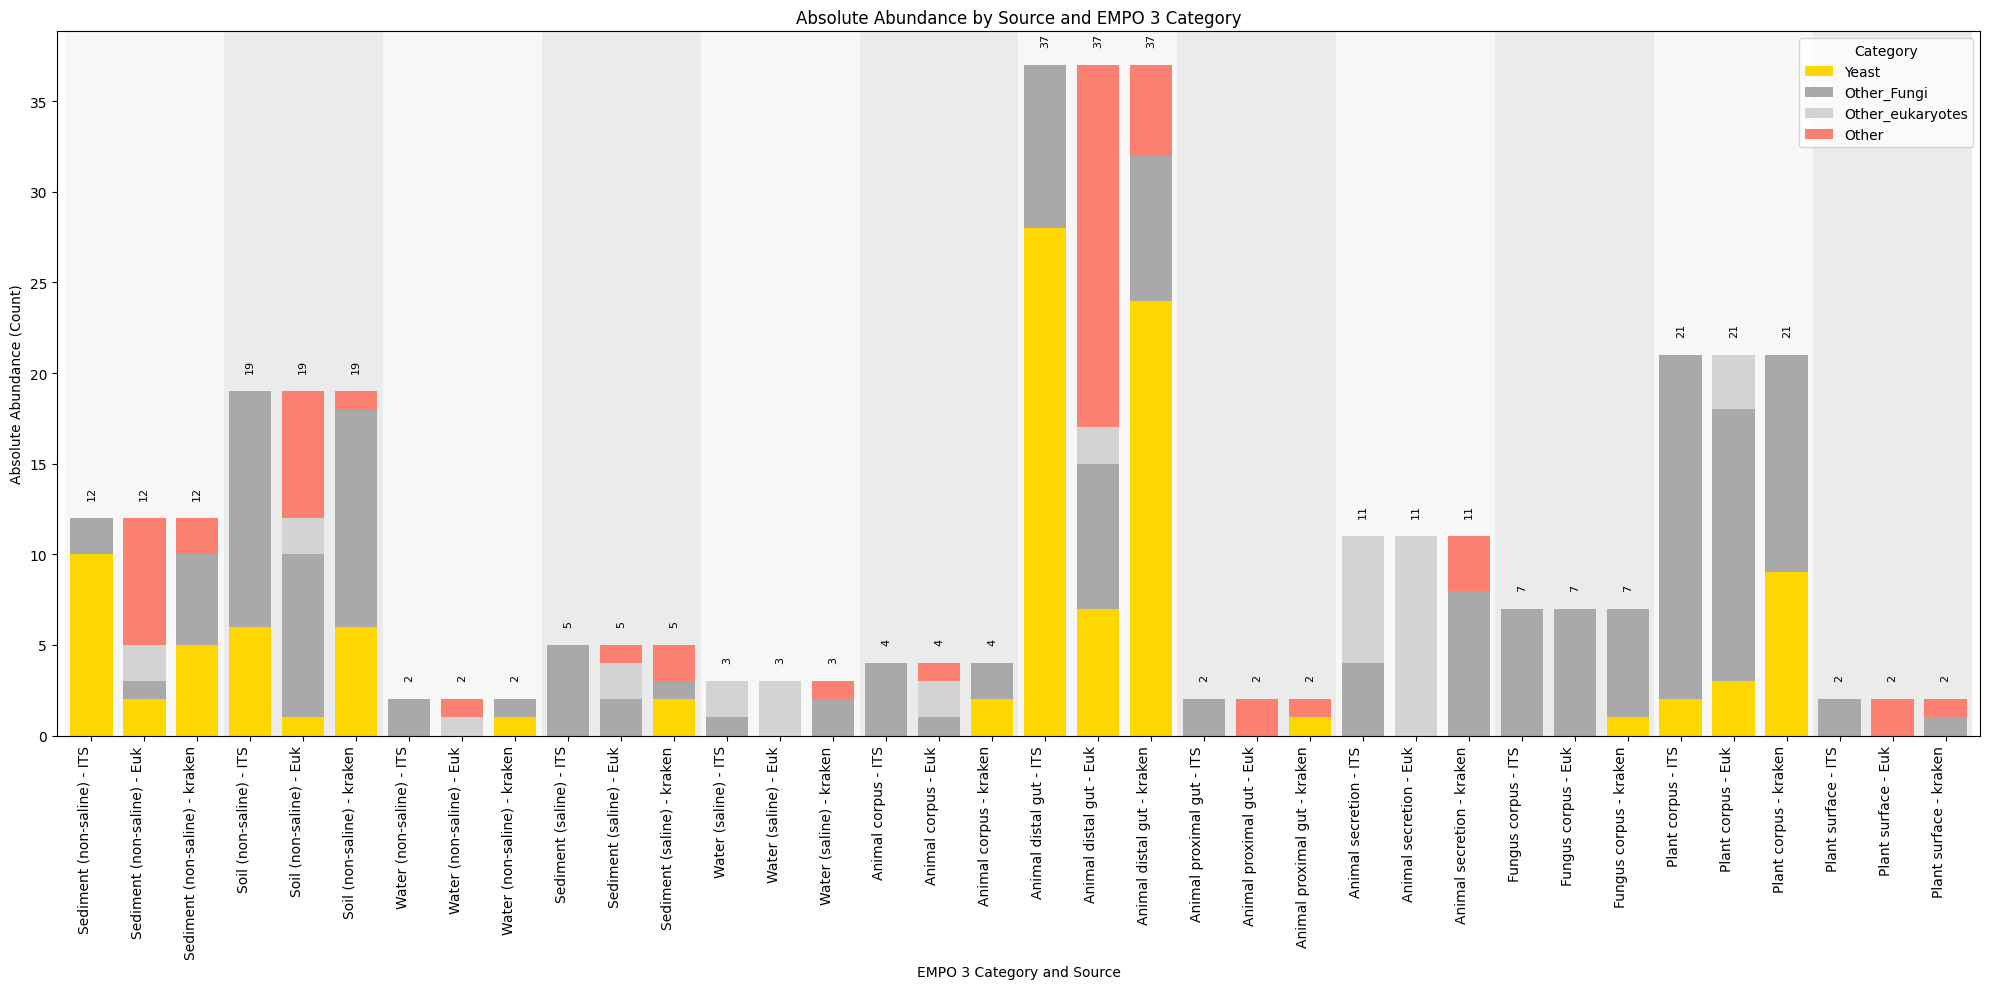

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the desired order for empo_3 categories (using the previously defined order from common rows)
# Using the common rows list from cell 0bb182e7 as the order
# Define the desired order for empo_3 categories
empo_3_order = ['Sediment (non-saline)','Soil (non-saline)', 'Water (non-saline)','Sediment (saline)','Water (saline)', 'Animal corpus', 'Animal distal gut', 'Animal proximal gut',  'Animal secretion', 'Fungus corpus', 'Plant corpus', 'Plant surface',]

# Define the desired order for Source categories
source_order = ['ITS', 'Euk', 'kraken']

# Define the order of categories for stacking and coloring in the plot
# Now including 'Other'
category_order = ['Yeast', 'Other_Fungi', 'Other_eukaryotes', 'Other']

# Define the colors for each category
colors = {'Yeast': 'gold', 'Other_Fungi': 'darkgray', 'Other_eukaryotes': 'lightgray', 'Other': 'salmon'} # Changed color for 'Other'

# Set index to empo_3 and Source before melting to create a MultiIndex
# This handles cases where empo_3 might not be unique across all sources
# Reset the index first to make 'empo_3' a column
combined_abs_indexed = combined_absolute_abundances.reset_index().set_index(['empo_3', 'Source'])


# Melt the combined_abs_indexed DataFrame to long-form for plotting
combined_abs_melted = combined_abs_indexed.melt(
    value_vars=category_order, # Melt the updated category columns
    var_name='Category',
    value_name='Absolute_Abundance',
    ignore_index=False # Keep the MultiIndex
)

# The melted dataframe now has a MultiIndex (empo_3, Source) and 'Category', 'Absolute_Abundance' columns
# We can directly pivot this for stacked plotting

# Pivot the data for stacked plotting
combined_abs_pivot = combined_abs_melted.pivot_table(
    index=['empo_3', 'Source'],
    columns='Category', # Stack by Category (Yeast, Other_Fungi, Other_eukaryotes, Other)
    values='Absolute_Abundance', # Use Absolute_Abundance as values
    fill_value=0
)
# Drop rows with NaN values
combined_abs_pivot = combined_abs_pivot.dropna()

# Reorder columns for desired stacking order
combined_abs_pivot = combined_abs_pivot[category_order]

# Reindex the pivot table to ensure the desired order of empo_3 and Source
# This should now work as the index is unique after the initial set_index
new_multi_index = pd.MultiIndex.from_product([empo_3_order, source_order], names=['empo_3', 'Source'])
combined_abs_pivot = combined_abs_pivot.reindex(new_multi_index)



combined_abs_pivot


# Create the stacked bar plot
plt.figure(figsize=(20, 10))
ax = combined_abs_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(20, 10),
    color=[colors[cat] for cat in category_order], # Colors for the stacked categories
    width=0.8 # Adjust bar width
)


# Add text labels on top of each stacked bar to display the 'Total_Samples' count.
# Need to calculate the position for the text labels. The text should be centered on the bar.
# The y-position should be at the top of the stacked bar (sum of abundances).
# We can get the total samples from the original combined_absolute_abundances DataFrame.

# Iterate over the bars to add text labels
for i, (index, row) in enumerate(combined_abs_pivot.iterrows()):
    empo_3, source = index
    print(empo_3,source,i)
    # Get the total samples for this empo_3 and source combination
    # Look up the Total_Samples from the original combined_absolute_abundances DataFrame.
    # Use .loc with the MultiIndex to handle potential missing combinations correctly.
    try:
        #print(Sediment (non-saline) ITS)
        val = combined_absolute_abundances.loc[(combined_absolute_abundances.index.get_level_values('empo_3') == empo_3)&
         (combined_absolute_abundances['Source'] == source),'Total_Samples']
            # Si esperas un único valor, conviértelo a escalar:
        total_samples  = val.iloc[0]
        print("I tried")
    except KeyError:
        # If the combination doesn't exist in the original dataframe,
        # it means Total_Samples is 0, which was handled during reindexing.
        total_samples = 0
        print("I tried but failed")



    # Calculate the height of the stacked bar (sum of absolute abundances)
    bar_height = row.sum()

    # Add the text label for Total_Samples at the top of the bar
    # Position the text at the center of the bar on the x-axis
    # Use the bar_height for the y-position
    ax.text(
        i,
        bar_height + 1, # Add a small offset above the bar
        str(int(total_samples)), # Convert to integer string
        ha='center', # Center horizontally
        va='bottom', # Align vertically to the bottom of the text
        fontsize=8, # Adjust font size as needed
        rotation=90 # Rotate text for better readability if needed
    )


# Add alternating background colors for empo_3 categories
num_empo_3_categories = len(empo_3_order)
bars_per_group = len(source_order)

for i in range(num_empo_3_categories):
    color = '#f0f0f0' if i % 2 == 0 else '#d9d9d9' # Light gray shades
    start_x = i * bars_per_group - 0.5
    end_x = (i + 1) * bars_per_group - 0.5
    ax.axvspan(start_x, end_x, facecolor=color, alpha=0.5, zorder=-1)


# Set plot title and labels
plt.title('Absolute Abundance by Source and EMPO 3 Category')
plt.xlabel('EMPO 3 Category and Source')
plt.ylabel('Absolute Abundance (Count)')

# Set the custom x-axis tick labels
# Create custom labels including empo_3 and source
x_labels = [f"{idx[0]} - {idx[1]}" for idx in combined_abs_pivot.index]
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=90, ha='right') # Rotate and adjust alignment

# Include a legend for the categories
plt.legend(title='Category')

# Adjust layout to prevent labels from overlapping.
plt.tight_layout()

# Display the plot.
plt.show()

<Figure size 2000x1000 with 0 Axes>

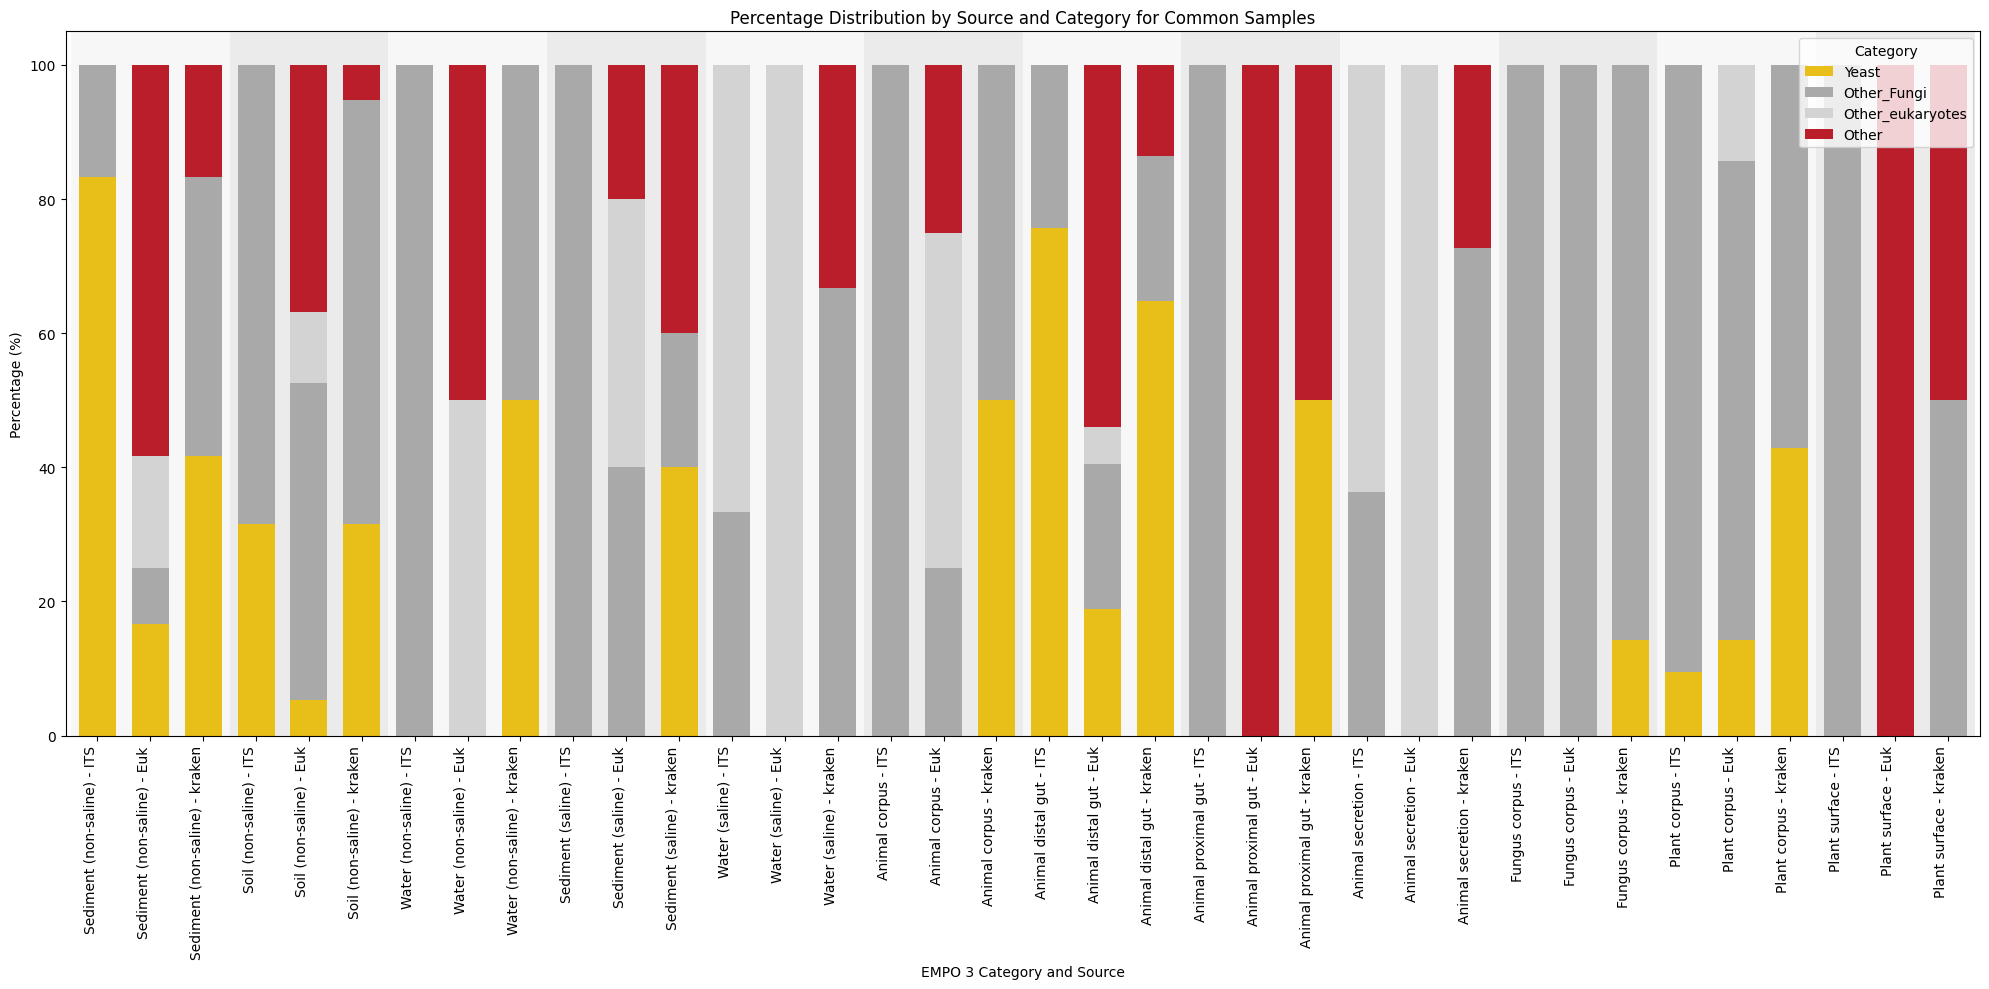

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Use combined_absolute_abundances to calculate percentages
# Calculate percentages for relevant columns based on 'Total_Samples'
combined_absolute_abundances_percentages = combined_absolute_abundances.copy()

# Calculate percentages for 'Yeast', 'Other_Fungi', 'Other_eukaryotes', and 'Other'
for col in ['Yeast', 'Other_Fungi', 'Other_eukaryotes', 'Other']:
    # Avoid division by zero if Total_Samples is 0
    combined_absolute_abundances_percentages[col] = (
        combined_absolute_abundances_percentages[col] / combined_absolute_abundances_percentages['Total_Samples']
    ) * 100
    combined_absolute_abundances_percentages[col] = combined_absolute_abundances_percentages[col].fillna(0) # Fill NaN with 0 after division


# Melt the DataFrame to long-form
combined_melted_percentages = combined_absolute_abundances_percentages.reset_index().melt(
    id_vars=['empo_3', 'Source'],
    value_vars=['Yeast', 'Other_Fungi', 'Other_eukaryotes', 'Other'], # Use the calculated percentage columns
    var_name='Category',
    value_name='Percentage'
)


# Define the desired order for empo_3 categories (using the previously defined order from common rows)
# Using the common rows list from cell 0bb182e7 as the order
empo_3_order = ['Sediment (non-saline)','Soil (non-saline)', 'Water (non-saline)','Sediment (saline)','Water (saline)', 'Animal corpus', 'Animal distal gut', 'Animal proximal gut',  'Animal secretion', 'Fungus corpus', 'Plant corpus', 'Plant surface',]

# Define the desired order for Source categories
source_order = ['ITS', 'Euk', 'kraken']

# Define the order of categories for stacking and coloring in the plot
# Now including 'Other_eukaryotes' and 'Other'
category_order = ['Yeast', 'Other_Fungi', 'Other_eukaryotes','Other'] # Updated category order


# Define the colors for each category
colors = {'Yeast': '#e7bf18', 'Other_Fungi': 'darkgray', 'Other_eukaryotes': 'lightgray','Other':'#bb1e2b'} # Updated colors


# Pivot the melted DataFrame for stacked plotting
combined_pivot_percentages = combined_melted_percentages.pivot_table(index=['empo_3', 'Source'], columns='Category', values='Percentage', fill_value=0)

# Reorder columns for desired stacking order
combined_pivot_percentages = combined_pivot_percentages[category_order]

# Reindex the combined_pivot_percentages DataFrame to ensure the desired order of empo_3 and Source
new_index_percentages = pd.MultiIndex.from_product([empo_3_order, source_order], names=['empo_3', 'Source'])
combined_pivot_percentages = combined_pivot_percentages.reindex(new_index_percentages).dropna()


# Create the stacked bar plot with adjusted bar width
plt.figure(figsize=(20, 10))
ax = combined_pivot_percentages.plot(kind='bar', stacked=True, figsize=(20, 10), color=[colors[cat] for cat in category_order], width=0.7) # Reduced width

# Add alternating background colors for empo_3 categories
num_empo_3_categories = len(empo_3_order)
bars_per_group = len(source_order)

for i in range(num_empo_3_categories):
    color = '#f0f0f0' if i % 2 == 0 else '#d9d9d9' # Light gray shades
    start_x = i * bars_per_group - 0.5
    end_x = (i + 1) * bars_per_group - 0.5
    ax.axvspan(start_x, end_x, facecolor=color, alpha=0.5, zorder=-1)


# Set plot title and labels
plt.title('Percentage Distribution by Source and Category for Common Samples')
plt.xlabel('EMPO 3 Category and Source')
plt.ylabel('Percentage (%)')

# Set the custom x-axis tick labels
# Create custom labels including empo_3 and source
x_labels = [f"{idx[0]} - {idx[1]}" for idx in combined_pivot_percentages.index]
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=90, ha='right') # Rotate and adjust alignment

# Include a legend for the categories
plt.legend(title='Category')

# Adjust layout to prevent labels from overlapping.
plt.tight_layout()

# Display the plot.
plt.show()

/tmp/ipython-input-1244808215.py:22: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  ax = sns.stripplot(


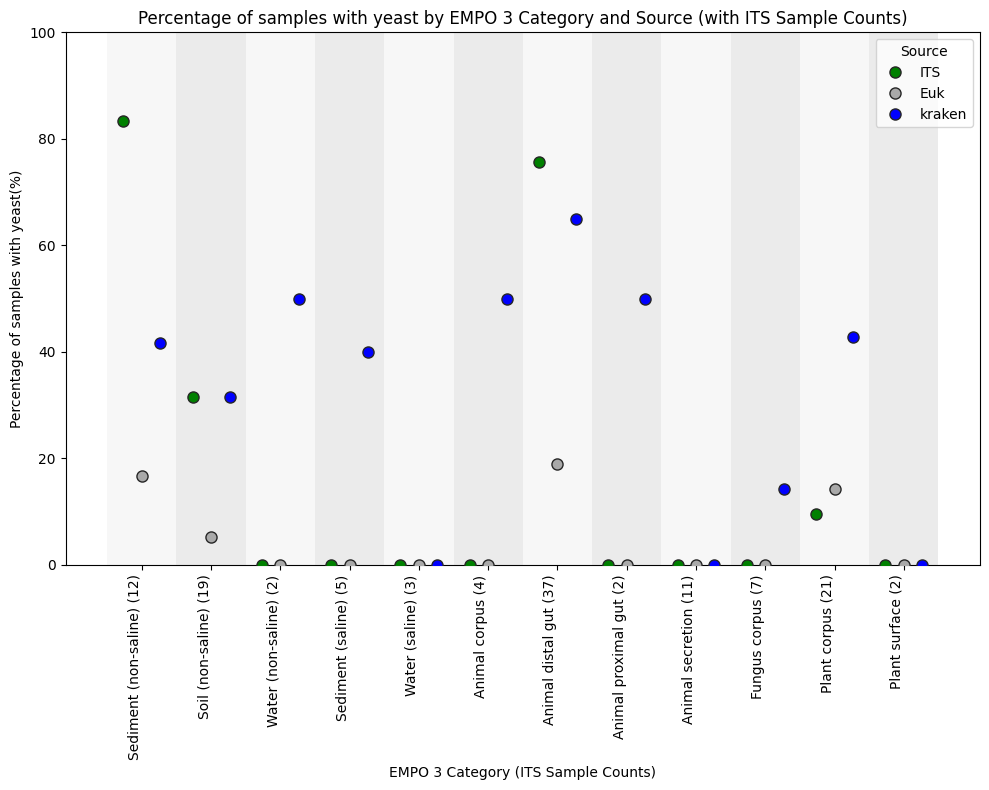

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Use the combined_absolute_abundances_percentages DataFrame which already has percentages
# Select only the 'Yeast' percentage and relevant columns
yeast_percentage_data = combined_absolute_abundances_percentages.reset_index()[['empo_3', 'Source', 'Yeast']]

# Rename the 'Yeast' column to 'Yeast Percentage' for clarity in the plot
yeast_percentage_data = yeast_percentage_data.rename(columns={'Yeast': 'Yeast Percentage'})


# Define the desired order for empo_3 categories
empo_3_order = ['Sediment (non-saline)','Soil (non-saline)', 'Water (non-saline)','Sediment (saline)','Water (saline)', 'Animal corpus', 'Animal distal gut', 'Animal proximal gut',  'Animal secretion', 'Fungus corpus', 'Plant corpus', 'Plant surface',]


# Define colors for each source
source_colors = {'ITS': 'green', 'Euk': 'darkgray', 'kraken': 'blue'} # Using similar colors as before

# Create the dot plot
plt.figure(figsize=(10, 8)) # Adjust figure size as needed
ax = sns.stripplot(
    data=yeast_percentage_data,
cassowary


whooping crane


sloth bear


Free living


Host associated


Free living


Host associated


Host associated


Animal associated
    x='empo_3',
    y='Yeast Percentage',
    hue='Source',
    order=empo_3_order, # Set the order of empo_3 categories on the x-axis
    palette=source_colors, # Use the defined colors
    size=8, # Adjust dot size
    jitter=True, # Add jitter to spread out points with the same value
    edgecolor='gray', # Add edge color to dots
    linewidth=1, # Adjust edge line width
    dodge=True # Add dodge to separate points by hue
)

# Set the y-axis limits to 0% and 100%
plt.ylim(0, 100)

# Add alternating background colors for empo_3 categories
num_empo_3_categories = len(empo_3_order)

for i in range(num_empo_3_categories):
    color = '#f0f0f0' if i % 2 == 0 else '#d9d9d9' # Light gray shades
    ax.axvspan(i - 0.5, i + 0.5, facecolor=color, alpha=0.5, zorder=-1)

# --- Modification to add Total Samples for ITS source to x-axis labels ---
# Get the Total Samples for the ITS source for each empo_3 category
# Ensure the index is reset and then set to 'empo_3' and 'Source' for correct slicing
its_total_samples_map = combined_absolute_abundances.reset_index().set_index(['empo_3', 'Source']).loc[(slice(None), 'ITS'), 'Total_Samples'].to_dict()

# Create custom labels in the format "empo_3 (Total Samples - ITS)"
# Iterate through the empo_3_order to ensure the labels match the plot order
custom_labels = []
for category in empo_3_order:
    # Get the total samples for this category and ITS source
    total_samples = its_total_samples_map.get((category, 'ITS'), 0) # Use .get with default 0
    custom_labels.append(f"{category} ({int(total_samples)})")

# Set the custom x-axis tick labels
ax.set_xticks(range(len(custom_labels)))
ax.set_xticklabels(custom_labels, rotation=90, ha='right') # Rotate and adjust alignment
# --- End of modification ---


# Set plot title and labels
plt.title('Percentage of samples with yeast by EMPO 3 Category and Source (with ITS Sample Counts)') # Updated title
plt.xlabel('EMPO 3 Category (ITS Sample Counts)') # Updated x-label title
plt.ylabel('Percentage of samples with yeast(%)')

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
# Save the plot as an SVG file
plt.savefig('absolute_abundance_plot.svg', format='svg')

<Figure size 640x480 with 0 Axes>

# Task
Generate a plot that shows the total number of samples for each combination of `empo_3` category and `source` (ITS, Euk, kraken), with stacked bars representing the percentage of samples that are 'Yeast', 'Other Fungi', and 'Other/No Fungi'. The bars should be ordered first by `empo_3` and then by `source` (ITS, Euk, kraken). The colors for 'Yeast' and 'Other Fungi' should be a gradient of 'bb1e2b', and 'Other/No Fungi' should be 'darkgray'.